### Okay para esta actividad tratare de utilizar todo de lo que me acuerdo e ir mejorandolo para poder repasar como se define la red neuronal, usare las librerias de pytorch

In [11]:
pip -q install torchmetrics

Note: you may need to restart the kernel to use updated packages.


**Cargar el dataset**

Para cargar el dataset no usare el que puso el profe, usare el de torchvision ya que esta mas sencillo, para este si me basare en como sale en internet y hare el split de train, val y hold-out test

In [1]:
# Imports genericos con chat gpt
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, TensorDataset

import matplotlib.pyplot as plt

In [2]:
# Checamos si tenemos CUDA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# Definimos la transformacion que le haremos al dataset
transform = transforms.ToTensor()

# Se llama la funcion MNIST de datasets. dentro de Torchvision, esto llama el MNIST que vamos a clasificar
full_train_dataset = datasets.MNIST(
    root= ('/root'), # Este le puse root pero algunos ejemplos ponen ./data despues de revisar lo que hice jajaj
    train= True, # Train subset
    transform= transform, # Se llama la trasnformacion a tensor
    download= True # Descargamos el dataset 
)

test_dataset = datasets.MNIST(
    root= ('/root'),
    train= False, # Este no es el train subset
    transform= transform,
    download= True
)

In [4]:
print(f"El tamano de nuestro subset de full train es: {len(full_train_dataset)}\n y el tamano de nuestro subset de val es: {len(test_dataset)}  ")


El tamano de nuestro subset de full train es: 60000
 y el tamano de nuestro subset de val es: 10000  


Okay ya tenemos el dataset, solo que falta quitar 10k del set de train y ponerlo en el set de test

In [5]:
# Esto no lo enseno el profe en clase y esta en el ejemplo de la red neuronal de github
# Trataremos implementarlo de memoria si no sale me baso en el ejemplo

train_dataset, val_dataset = random_split(full_train_dataset, [50000, 10000])

Okay hicimos el slicing de y , x del train para ponerlo en test ahora si se supone que tenemos 50k, 10k y 10k. Podremos llamar los dataloaders, 

In [6]:
train_loader= DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader= DataLoader(dataset=val_dataset, batch_size=64, shuffle=True)
test_loader= DataLoader(dataset=test_dataset, batch_size=64, shuffle=True)  

In [12]:
print(len(train_loader.dataset))
print(len(val_loader.dataset))
print(len(test_loader.dataset))

50000
10000
10000


**Definimos la funcion de entrenamiento**

In [19]:
from tqdm import tqdm 
import numpy as np
from torchmetrics import Accuracy


def train_function(train_loader,val_loader, optimizer,loss_fn, epochs,model, device): # ahora hasta paso el device jaja por el CUDA
    epoch_train_loss = []
    epoch_val_loss = []
    epoch_train_acc = []
    epoch_val_acc = []
    metric = Accuracy(task="multiclass", num_classes=10).to(device)
    best_val_acc = 0.0
    

    for epoch in range(epochs):
        model.train()    # modo entrenamiento
        train_losses = []
        train_accs = []
        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
            optimizer.zero_grad() # Reiniciamos los gradientes de error ya que en cada batch se reinician y se actualizan pesos

            X_batch = X_batch.to(device) # Estos solo los agregue porque me salio un error de que el xbatch y el modelo estaban en diferentes lados
            y_batch = y_batch.to(device) # Uno en CPU y el otro en GPU jaja no entiendo porque si no lo habia usado antes y no tenia problema pero bueno

            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            acc = metric(pred, y_batch) 

            loss.backward()   # Calculamos el error distribuido en capas a traves de la red neuronal
            optimizer.step() # Actualizamos los pesos

            train_losses.append(loss.item())
            train_accs.append(acc.item())

        epoch_train_loss.append(np.mean(train_losses))
        epoch_train_acc.append(np.mean(train_accs))


        model.eval()
        val_losses = []
        val_accs = []
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device) # Same que arriba
                y_val = y_val.to(device)

                val_pred = model(X_val)
                val_loss = loss_fn(val_pred, y_val)
                val_acc = metric(val_pred, y_val) 
                val_losses.append(val_loss.item())
                val_accs.append(val_acc.item())

        epoch_val_loss.append(np.mean(val_losses))
        epoch_val_acc.append(np.mean(val_accs))

        print(f"epoch {epoch+1} loss: {epoch_train_loss[-1]:.2f} (train) | {epoch_val_loss[-1]:.2f} (val) , acc: {epoch_train_acc[-1]:.2f} (train) | {epoch_val_acc[-1]:.2f} (val)")
        
        if epoch_val_acc[-1] > best_val_acc:
            best_val_acc = epoch_val_acc[-1]
            print(f"Epoch {epoch+1} guardado, hasta ahorita es el mejor")

    return epoch_train_loss, epoch_val_loss, epoch_train_acc, epoch_val_acc


**Definimos arquitectura de Red Neuronal**

Para esta arquitectura, pues tenemos una buena cantidad de datos y la verdad en vez de dejar pequenas capas me gustaria tener muchas capas ocultas y muchas neuronas, quiero saber si hace overfitting o como seria su desempeno

(Primero defini la arquitectura de la NN pero me estoy dando cuenta mejor lo paso para abajo lacelda para poder hacer la llamada de la funcion mas comodo)

In [20]:
DNN1 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 1250),
    nn.ReLU(),
    nn.Linear(1250, 1250),
    nn.ReLU(),
    nn.Linear(1250, 1000),
    nn.ReLU(),
    nn.Linear(1000, 1000),
    nn.ReLU(),
    nn.Linear(1000, 750),
    nn.ReLU(),
    nn.Linear(750, 500),
    nn.ReLU(),
    nn.Linear(500, 250),
    nn.ReLU(),
    nn.Linear(250, 50),
    nn.ReLU(),
    nn.Linear(50, 10),
).to(device)

loss = nn.CrossEntropyLoss()  # CrossEntropyLoss es la funcion de perdida para clasificacion multiclase y aplica softmax() internamente
optimizer = optim.Adam(
    params= DNN1.parameters(),
    lr=0.0001 # Learning rate bajo porque tenemos una red profundo yo creo que si alcanza a aprender jaja
)
epochs = 50
batch_size= 64

**llamamos las funciones y graficamos tqdm de one**

In [21]:
# llamamos la funcion que acabamos de crear

DNN1epoch_train_loss, DNN1epoch_val_loss, DNN1epoch_train_acc, DNN1epoch_val_acc = train_function(
    train_loader, 
    val_loader, 
    optimizer,
    loss, 
    epochs, 
    DNN1,
    device
    )

Epoch 1/50: 100%|██████████| 782/782 [00:05<00:00, 133.71it/s]


epoch 1 loss: 0.57 (train) | 0.21 (val) , acc: 0.81 (train) | 0.94 (val)
Epoch 1 guardado, hasta ahorita es el mejor


Epoch 2/50: 100%|██████████| 782/782 [00:05<00:00, 141.68it/s]


epoch 2 loss: 0.17 (train) | 0.17 (val) , acc: 0.95 (train) | 0.95 (val)
Epoch 2 guardado, hasta ahorita es el mejor


Epoch 3/50: 100%|██████████| 782/782 [00:05<00:00, 135.36it/s]


...

epoch 48 loss: 0.01 (train) | 0.10 (val) , acc: 1.00 (train) | 0.98 (val)


Epoch 49/50: 100%|██████████| 782/782 [00:05<00:00, 135.78it/s]


epoch 49 loss: 0.00 (train) | 0.13 (val) , acc: 1.00 (train) | 0.98 (val)


Epoch 50/50: 100%|██████████| 782/782 [00:05<00:00, 131.37it/s]


epoch 50 loss: 0.00 (train) | 0.11 (val) , acc: 1.00 (train) | 0.98 (val)


**Reusamos codigo y ploteamos las graficas de val y acc**

In [22]:
# Ploteamos las curvas de loss

def plot_loss_curves(train_losses, val_losses):
    #Ok yo estaba pasando num_epochs crudo y eso me dio error varias veces, tengo que construir la lista con range como el ejemplo de la diapositiva
    epochs_updated = range(1, len(train_losses)+1 )

    plt.plot(epochs_updated,train_losses, label="Curva de perdida del entrenamiento")
    plt.plot(epochs_updated,val_losses, label="Curva de perdida en validacion")
    plt.xlabel("Epoch")
    plt.ylabel("Perdida")
    plt.title("Curvas de perdida")
    plt.legend()
    plt.show()

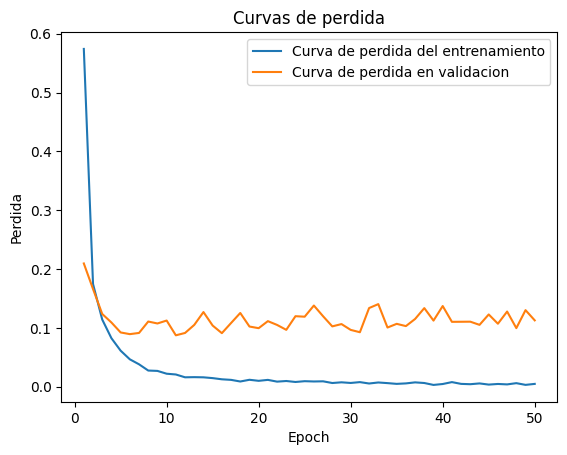

In [23]:
plot_loss_curves(DNN1epoch_train_loss, DNN1epoch_val_loss)

In [24]:
# Ploteamos las curvas de accuracy

def plot_acc_curves(train_accs, val_accs):
    #Ok yo estaba pasando num_epochs crudo y eso me dio error varias veces, tengo que construir la lista con range como el ejemplo de la diapositiva
    epochs_updated = range(1, len(train_accs)+1 )

    plt.plot(epochs_updated,train_accs, label="Curva de accuracy del entrenamiento")
    plt.plot(epochs_updated,val_accs, label="Curva de accuracy en validacion")
    plt.xlabel("Epoch")
    plt.ylabel("accuracy")
    plt.title("Curvas de accuracy")
    plt.legend()
    plt.show()

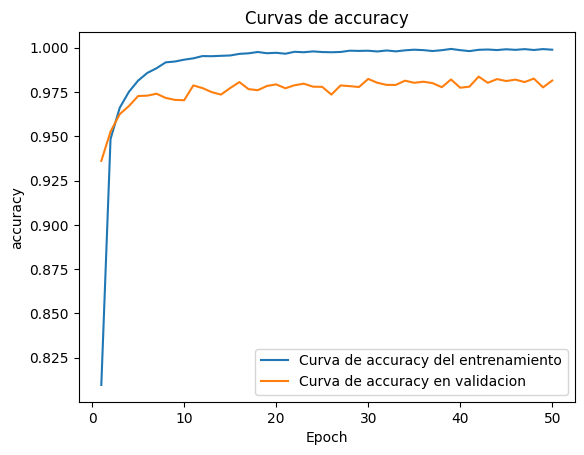

In [25]:
plot_acc_curves(DNN1epoch_train_acc, DNN1epoch_val_acc)

**Evaluacion final en test hold-out set**

In [26]:
metric = Accuracy(task="multiclass", num_classes=10).to(device)

test_loss_batch = 0.0
test_acc_batch = 0.0
DNN1.eval()
with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test = X_test.to(device)
        y_test = y_test.to(device)
        
        test_outputs = DNN1(X_test)
        test_loss_batch += loss(test_outputs, y_test).item() * X_test.size(0)
        test_acc_batch += metric(test_outputs, y_test) .item() * X_test.size(0)

test_loss = test_loss_batch / len(test_loader.dataset)
test_acc = test_acc_batch / len(test_loader.dataset)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")



Test Loss : 0.1142
Test acc : 0.9822


**Remarks**

Okay, DEFINITIVAMENTE hay overfitting o bueno mas bien se necesita un early stopping porque como desde el epoch 10 ya no valia la pena seguir con el entrenamiento jajaja, la verdad es que es una red GRANDISIMA para un dataset no tan complejo como este, aun asi tuvimos 0.98 de acc lo cual se me hace perfecto y un test loss considerable

Ahora me concentrare en definir 2 arquitecturas mas de red neuronal. 1 mas pequena y otra con Dropout para ver como se comporta

**Segunda arquitectura (Dropout)**

In [ ]:
DNN1 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 1250),
    nn.ReLU(),
    nn.Linear(1250, 1250),
    nn.ReLU(),
    nn.Linear(1250, 1000),
    nn.ReLU(),
    nn.Linear(1000, 1000),
    nn.ReLU(),
    nn.Linear(1000, 750),
    nn.ReLU(),
    nn.Linear(750, 500),
    nn.ReLU(),
    nn.Linear(500, 250),
    nn.ReLU(),
    nn.Linear(250, 50),
    nn.ReLU(),
    nn.Linear(50, 10),
).to(device)

loss = nn.CrossEntropyLoss()  # CrossEntropyLoss es la funcion de perdida para clasificacion multiclase y aplica softmax() internamente
optimizer = optim.Adam(
    params= DNN1.parameters(),
    lr=0.0001 # Learning rate bajo porque tenemos una red profundo yo creo que si alcanza a aprender jaja
)
epochs = 50
batch_size= 64